# PyTorch Tutorial

Paul J. Atzberger<br> 
<https://web.atzberger.org/>

# Broadcasting

**Broadcasting** lets PyTorch perform arithmetic on tensors that don't have
the same shape. Allows operations without need to make extra copies of the data.

Understanding broadcasting is essential for writing compact, efficient machine learning codes. Once you internalize the four rules below you will be able to predict the output shape of almost any operation readily.

### The Four Broadcasting Rules

PyTorch follows the same broadcasting semantics as NumPy.
Given two tensors `A` and `B`, PyTorch applies these rules **in order**:

1. **Right-align shapes and pad with 1s.**  
   If `A` and `B` have different numbers of dimensions, prepend `1`s to the
   shape of the tensor with *fewer* dimensions until both shapes have the same
   length.

2. **Expand size-1 dimensions.**  
   In every dimension where one tensor has size `1` and the other has size `n > 1`,
   the size-1 tensor is *virtually* replicated `n` times along that dimension. No data is copied.

3. **All remaining sizes must match.**  
   After rules 1 and 2, if any dimension still has two *different* sizes (neither
   of which is 1), PyTorch raises a `RuntimeError`.

4. **The output shape is the element-wise maximum of the (aligned) shapes.**  
   For each dimension, `output_size = max(A_size, B_size)`.

The rest of this notebook works through concrete examples for each rule.

In [1]:
import torch
import matplotlib.pyplot as plt

def shapes(a, b, result):
    """Helper: print the shapes involved in an operation."""
    print(f"  A shape: {tuple(a.shape)}")
    print(f"  B shape: {tuple(b.shape)}")
    print(f"  result : {tuple(result.shape)}")

---
## Rule 1: Right-align and pad with 1s

When the two tensors have different numbers of dimensions, the shorter shape
is padded on the **left** with `1`s.

```
A : shape (3,)     →  (1, 3)   after padding
B : shape (2, 3)
```

After alignment both shapes are `(2, 3)` → result is `(2, 3)`.

In [2]:
# A 1-D tensor added to a 2-D tensor
A = torch.tensor([1.0, 2.0, 3.0])          # shape (3,)
B = torch.tensor([[10.0, 20.0, 30.0],      # shape (2, 3)
                  [40.0, 50.0, 60.0]])

result = A + B
print("A + B:")
shapes(A, B, result)
print(result)
# A is treated as [[1, 2, 3], [1, 2, 3]] -added to every row of B

A + B:
  A shape: (3,)
  B shape: (2, 3)
  result : (2, 3)
tensor([[11., 22., 33.],
        [41., 52., 63.]])


In [3]:
# A scalar (0-D) broadcasts with anything
x = torch.randn(3, 4, 5)
result = x * 2.0
print("scalar × tensor:", tuple(x.shape), "→", tuple(result.shape))

scalar × tensor: (3, 4, 5) → (3, 4, 5)


---
## Rule 2: Expand size-1 dimensions

Once shapes are aligned, any dimension that is `1` in one tensor is expanded
to match the other.

```
A : shape (4, 1)   →  (4, 3) after expansion
B : shape (1, 3)   →  (4, 3) after expansion
result             :  (4, 3)
```

In [4]:
A = torch.arange(1, 5).reshape(4, 1).float()   # column vector  (4, 1)
B = torch.arange(1, 4).reshape(1, 3).float()   # row vector     (1, 3)

result = A + B
print("A (column vector):")
print(A)
print("B (row vector):")
print(B)
print("A + B  (outer sum):")
shapes(A, B, result)
print(result)

A (column vector):
tensor([[1.],
        [2.],
        [3.],
        [4.]])
B (row vector):
tensor([[1., 2., 3.]])
A + B  (outer sum):
  A shape: (4, 1)
  B shape: (1, 3)
  result : (4, 3)
tensor([[2., 3., 4.],
        [3., 4., 5.],
        [4., 5., 6.],
        [5., 6., 7.]])


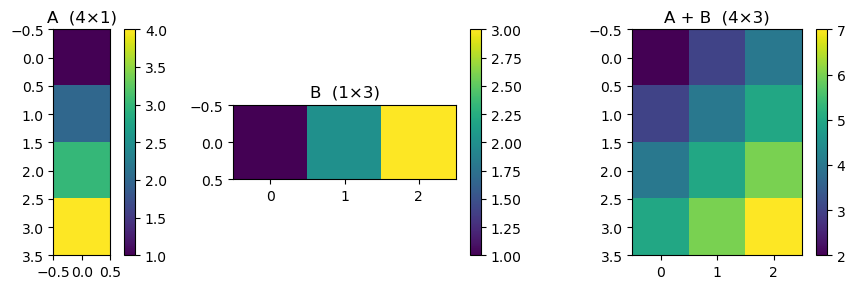

In [5]:
# Visualize the outer sum as a heatmap
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
titles = ["A  (4×1)", "B  (1×3)", "A + B  (4×3)"]
data   = [A.numpy(), B.numpy(), result.numpy()]

for ax, d, title in zip(axes, data, titles):
    im = ax.imshow(d, cmap="viridis")
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

---
## Rule 3: Incompatible shapes raise an error

If two dimensions are both greater than 1 and are *not equal*, broadcasting
cannot resolve the mismatch and PyTorch raises a `RuntimeError`.

In [6]:
A = torch.ones(2, 3)   # shape (2, 3)
B = torch.ones(2, 4)   # shape (2, 4) -column count differs: 3 ≠ 4

try:
    _ = A + B
except RuntimeError as e:
    print("RuntimeError:", e)

RuntimeError: The size of tensor a (3) must match the size of tensor b (4) at non-singleton dimension 1


In [7]:
# Fix: reshape one of the tensors so a dimension becomes 1
A = torch.ones(2, 3)      # (2, 3)
B = torch.ones(2, 1)      # (2, 1) -now compatible, expands to (2, 3)
print((A + B).shape)      # (2, 3)

torch.Size([2, 3])


---
## Rule 4: Output shape is the element-wise maximum

After applying rules 1–3, the output shape in each dimension is
`max(size_A, size_B)`.

```
A : (5, 1, 4)
B : (   3, 1)   →  padded to (1, 3, 1)
output: (max(5,1), max(1,3), max(4,1)) = (5, 3, 4)
```

In [8]:
A = torch.zeros(5, 1, 4)
B = torch.zeros(   3, 1)

result = A + B
print("A shape:", tuple(A.shape))       # (5, 1, 4)
print("B shape:", tuple(B.shape))       # (3, 1)
print("result :", tuple(result.shape))  # (5, 3, 4)

A shape: (5, 1, 4)
B shape: (3, 1)
result : (5, 3, 4)


---
## Practical Patterns

Broadcasting shows up constantly in machine learning codes. Below are some
common patterns. Also, see our github codes for more examples in practice https://github.com/atzberg.

In [9]:
# Pattern 1: adding a bias vector to a batch of predictions
#   batch   shape: (batch_size, features) = (32, 10)
#   bias    shape: (features,)            = (10,)
#   Rule 1 pads bias to (1, 10), then Rule 2 expands to (32, 10)

batch = torch.randn(32, 10)
bias  = torch.randn(10)

out = batch + bias
print("batch + bias:", tuple(out.shape))  # (32, 10)

batch + bias: (32, 10)


In [10]:
# Pattern 2: per-channel normalisation of an image batch
#   images  shape: (N, C, H, W) = (8, 3, 64, 64)
#   mean    shape: (C,)         = (3,)  →  needs to become (1, 3, 1, 1)

images = torch.randn(8, 3, 64, 64)
mean   = torch.tensor([0.485, 0.456, 0.406])  # ImageNet channel means
std    = torch.tensor([0.229, 0.224, 0.225])

# Reshape to (1, 3, 1, 1) so broadcasting aligns on the channel dim
mean = mean.reshape(1, 3, 1, 1)
std  = std.reshape(1, 3, 1, 1)

normalised = (images - mean) / std
print("normalised shape:", tuple(normalised.shape))  # (8, 3, 64, 64)

normalised shape: (8, 3, 64, 64)


In [11]:
# Pattern 3: pairwise distances between two sets of points
#   Set A: (N, D) -N points in D dimensions
#   Set B: (M, D) -M points in D dimensions
#   Goal : (N, M) matrix of squared distances

N, M, D = 5, 7, 3
A = torch.randn(N, D)   # (5, 3)
B = torch.randn(M, D)   # (7, 3)

# Reshape A to (N, 1, D) and B to (1, M, D); broadcasting gives (N, M, D)
diff = A.unsqueeze(1) - B.unsqueeze(0)   # (5, 1, 3) - (1, 7, 3) → (5, 7, 3)
sq_dist = (diff ** 2).sum(dim=-1)         # (5, 7)

print("pairwise squared distances shape:", tuple(sq_dist.shape))  # (5, 7)

pairwise squared distances shape: (5, 7)


---
## Visualizing Broadcasting

The diagram below shows what actually happens when a `(4,1)` column and a
`(1,5)` row are added. Note, neither tensor is physically copied. 

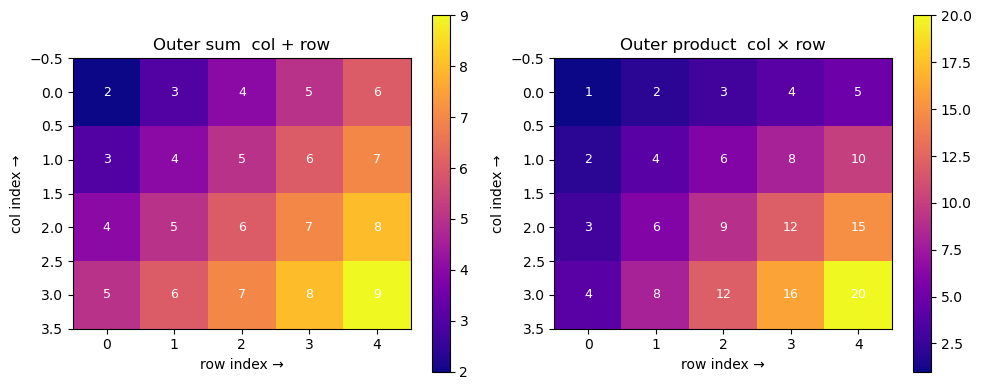

In [12]:
col = torch.arange(1, 5).reshape(4, 1).float()   # [1, 2, 3, 4]ᵀ
row = torch.arange(1, 6).reshape(1, 5).float()   # [1, 2, 3, 4, 5]

outer_sum = col + row   # (4, 5)
outer_prod = col * row  # (4, 5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, data, title in zip(axes,
                           [outer_sum, outer_prod],
                           ["Outer sum  col + row",
                            "Outer product  col × row"]):
    im = ax.imshow(data.numpy(), cmap="plasma", origin="upper")
    ax.set_title(title)
    ax.set_xlabel("row index →")
    ax.set_ylabel("col index →")
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{int(data[i,j])}",
                    ha="center", va="center", color="white", fontsize=9)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

---
## Quick Reference: Broadcasting Rules

| Rule | What happens |
|------|--------------|
| 1. Pad with 1s | Shorter shape gets `1`s prepended until dims match |
| 2. Expand size-1 | Size-1 dims are replicated to match the other tensor |
| 3. Must match | After rules 1–2, any dim mismatch (both > 1) → error |
| 4. Output shape | `max(size_A, size_B)` in every dimension |

**Tip:** Use `tensor.unsqueeze(dim)` to insert a size-1 dimension and explicitly
control which axis gets broadcast. This makes code easier to read than relying
on implicit left-padding.

For more examples in practice, you can also see our github codes at https://github.com/atzberg.

**Next:** [[03_neural_networks.ipynb]](03_neural_networks.ipynb) &nbsp; We next explain the basics of neural networks in PyTorch. 